# Интегрирование

In [24]:
!g++ -O3 -std=c++14 -pthread task1_integrate.cpp integrator.cpp -o task1_integrate

In [25]:
import subprocess
import numpy as np
import scipy.integrate as integrate
import warnings
import sys
import os

sys.path.append(r"D:\git\MIPT\tools")
from plot_tools import plot_signals

# Игнорируем варнинги SciPy из-за бешеных осцилляций sin(1/x) у нуля
warnings.filterwarnings("ignore", category=integrate.IntegrationWarning)

In [26]:
threads_list = np.arange(1, 13) 
a, b = 1e-16, 1.0     
eps = 1e-9
N = 10000             # Строго четное число
max_depth = 30

print("=" * 90)
print(f"Интегрирование sin(1/x) на [{a}, {b}], Целевая точность: {eps}")
print("=" * 90)

Интегрирование sin(1/x) на [1e-16, 1.0], Целевая точность: 1e-09


In [27]:

# --- ЭТАЛОН ЧЕРЕЗ SCIPY ---
def f(x):
    return np.sin(1/x)

print("Вычисление эталонного значения (scipy.integrate.quad)...")
ref_val, ref_err = integrate.quad(f, a, b, limit=5000, epsabs=eps)
print(f"Эталон SciPy: {ref_val:.12f} (Оценка ошибки: {ref_err:.2e})")
print("-" * 90)

Вычисление эталонного значения (scipy.integrate.quad)...
Эталон SciPy: 0.504066893732 (Оценка ошибки: 5.72e-08)
------------------------------------------------------------------------------------------


In [28]:
# --- ЗАПУСК C++ КОДА ---
times = []

for t in threads_list:
    cmd = f'./task1_integrate {t} {a} {b} {eps} {N} {max_depth}'
    
    result = subprocess.run(cmd.split(), capture_output=True, text=True)
    
    t_val, i_val, e_val = 0.0, 0.0, 0.0
    for line in result.stdout.split('\n'):
        if 'Time:' in line:
            t_val = float(line.split(':')[1].strip())
            times.append(t_val)
        if 'Integral:' in line:
            i_val = float(line.split(':')[1].strip())
        if 'Error:' in line:
            e_val = float(line.split(':')[1].strip())
            
    diff = abs(i_val - ref_val)
    print(f"Потоков: {t:2d} | Интеграл: {i_val:.10f} | Откл. от SciPy: {diff:.2e} | Оценка погрешности: {e_val:.2e} | Время: {t_val:.4f} с")

times = np.array(times)
threads_arr = np.array(threads_list)

Потоков:  1 | Интеграл: 0.5040670000 | Откл. от SciPy: 1.06e-07 | Оценка погрешности: 2.44e-11 | Время: 2.5266 с
Потоков:  2 | Интеграл: 0.5040670000 | Откл. от SciPy: 1.06e-07 | Оценка погрешности: 2.44e-11 | Время: 1.2451 с
Потоков:  3 | Интеграл: 0.5040670000 | Откл. от SciPy: 1.06e-07 | Оценка погрешности: 2.44e-11 | Время: 0.8299 с
Потоков:  4 | Интеграл: 0.5040670000 | Откл. от SciPy: 1.06e-07 | Оценка погрешности: 2.44e-11 | Время: 0.6341 с
Потоков:  5 | Интеграл: 0.5040670000 | Откл. от SciPy: 1.06e-07 | Оценка погрешности: 2.44e-11 | Время: 0.5210 с
Потоков:  6 | Интеграл: 0.5040670000 | Откл. от SciPy: 1.06e-07 | Оценка погрешности: 2.44e-11 | Время: 0.4525 с
Потоков:  7 | Интеграл: 0.5040670000 | Откл. от SciPy: 1.06e-07 | Оценка погрешности: 2.44e-11 | Время: 0.4582 с
Потоков:  8 | Интеграл: 0.5040670000 | Откл. от SciPy: 1.06e-07 | Оценка погрешности: 2.44e-11 | Время: 0.3582 с
Потоков:  9 | Интеграл: 0.5040670000 | Откл. от SciPy: 1.06e-07 | Оценка погрешности: 2.44e-11 |

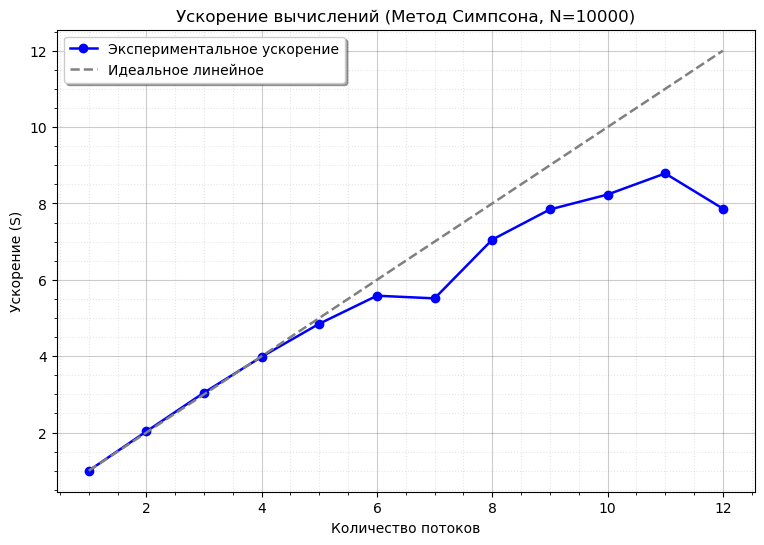

In [29]:
speedups = times[0] / times    # S = T1 / Tp
ideal_speedups = threads_arr   # Идеальное линейное ускорение

plot_signals(
    y=[speedups, ideal_speedups],
    x=[threads_arr, threads_arr],
    labels=["Экспериментальное ускорение", "Идеальное линейное"],
    title=f"Ускорение вычислений (Метод Симпсона, N={N})",
    xlabel="Количество потоков",
    ylabel="Ускорение (S)",
    markers=['o', ''],
    linestyles=['-', '--'],
    colors=['blue', 'gray'],
    figsize=(9, 6)
)

# Сортировка слиянием

In [30]:
!g++ -O3 -std=c++14 -pthread task2_sort.cpp mergesort.cpp -o task2_sort
!g++ -O3 -std=c++14 task2_qsort.cpp -o task2_qsort

In [36]:
# Параметры запуска
threads_list = np.arange(1, 13)
N = 10**7       
input_bin = "array.bin"
output_bin = "sorted.bin"

In [37]:

print(f"Генерация массива из {N} элементов (около {N*8 / 1e6} МБ)...")
data = np.random.rand(N).astype(np.float64)
data.tofile(input_bin)
print("Массив успешно сгенерирован и сохранен.\n")

Генерация массива из 10000000 элементов (около 80.0 МБ)...
Массив успешно сгенерирован и сохранен.



In [38]:
print("=" * 75)
print("Запуск эталонной сортировки (std::qsort)...")

qsort_result = subprocess.run(['./task2_qsort', input_bin], capture_output=True, text=True)
q_time = float(qsort_result.stdout.split(':')[1].strip())
print(f"Время эталона (std::qsort): {q_time:.4f} с")
print("=" * 75)

Запуск эталонной сортировки (std::qsort)...
Время эталона (std::qsort): 3.4082 с


In [39]:
merge_times = []

for t in threads_list:
    cmd = f'./task2_sort {t} {input_bin} {output_bin}'
    result = subprocess.run(cmd.split(), capture_output=True, text=True)

    m_time = 0.0
    for line in result.stdout.split('\n'):
        if 'MergeSort Time:' in line:
            m_time = float(line.split(':')[1].strip())
            merge_times.append(m_time)

    # Проверяем массив на корректность только для первого запуска, 
    # чтобы не тратить время питона
    if t == 1 or t == 2:
        sorted_data = np.fromfile(output_bin, dtype=np.float64)
        is_sorted = np.all(np.diff(sorted_data) >= 0)
        status = "УСПЕХ" if is_sorted else "ОШИБКА"
        print(f"{t}: {status}")

    print(f"Потоков: {t:2d} | MergeSort: {m_time:.4f} с | Ускорение относительно qsort: {q_time/m_time:.2f}x")

merge_times = np.array(merge_times)
threads_arr = np.array(threads_list)

# Освобождаем место на диске
if os.path.exists(input_bin): os.remove(input_bin)
if os.path.exists(output_bin): os.remove(output_bin)

1: УСПЕХ
Потоков:  1 | MergeSort: 2.6559 с | Ускорение относительно qsort: 1.28x
2: УСПЕХ
Потоков:  2 | MergeSort: 1.3851 с | Ускорение относительно qsort: 2.46x
Потоков:  3 | MergeSort: 0.9989 с | Ускорение относительно qsort: 3.41x
Потоков:  4 | MergeSort: 0.8131 с | Ускорение относительно qsort: 4.19x
Потоков:  5 | MergeSort: 0.7753 с | Ускорение относительно qsort: 4.40x
Потоков:  6 | MergeSort: 0.6668 с | Ускорение относительно qsort: 5.11x
Потоков:  7 | MergeSort: 0.6013 с | Ускорение относительно qsort: 5.67x
Потоков:  8 | MergeSort: 0.5467 с | Ускорение относительно qsort: 6.23x
Потоков:  9 | MergeSort: 0.5501 с | Ускорение относительно qsort: 6.20x
Потоков: 10 | MergeSort: 0.5274 с | Ускорение относительно qsort: 6.46x
Потоков: 11 | MergeSort: 0.5280 с | Ускорение относительно qsort: 6.45x
Потоков: 12 | MergeSort: 0.5254 с | Ускорение относительно qsort: 6.49x


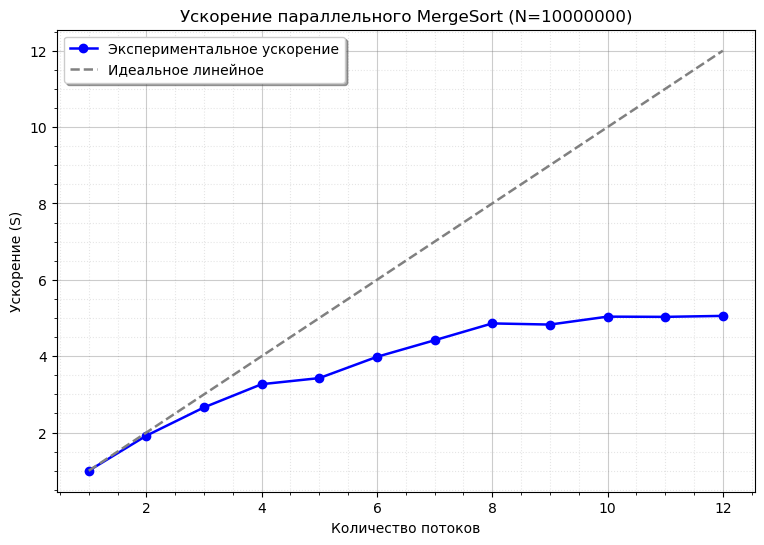

In [40]:
speedups = merge_times[0] / merge_times
ideal_speedups = threads_arr

plot_signals(
    y=[speedups, ideal_speedups],
    x=[threads_arr, threads_arr],
    labels=["Экспериментальное ускорение", "Идеальное линейное"],
    title=f"Ускорение параллельного MergeSort (N={N})",
    xlabel="Количество потоков",
    ylabel="Ускорение (S)",
    markers=['o', ''],
    linestyles=['-', '--'],
    colors=['blue', 'gray'],
    figsize=(9, 6)
)